In [1]:
# BLOCK 1: Imports and Setup
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef
from google.colab import drive

# Set random seeds so our results are reproducible
tf.random.set_seed(42)
np.random.seed(42)

# Mount Google Drive (A popup will ask for permission)
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# BLOCK 2: Data Cleaning (Cropping out black background)

# Define paths (Update original_dataset_path if your folder name is slightly different)
original_dataset_path = "/content/drive/MyDrive/Alzheimer_dataset"
clean_dataset_path = "/content/drive/MyDrive/Alzheimer_Cleaned_Dataset"

# Create the new master directory
os.makedirs(clean_dataset_path, exist_ok=True)

def crop_brain_contour(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Threshold to find the brain (ignore pure black pixels)
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        # Crop the image to just the brain bounding box
        cropped_img = img[y:y+h, x:x+w]
        resized_img = cv2.resize(cropped_img, (224, 224))
        cv2.imwrite(save_path, resized_img)
    else:
        cv2.imwrite(save_path, cv2.resize(img, (224, 224)))

classes = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
print("Starting Data Cleaning Process (This may take a few minutes)...\n")

for class_name in classes:
    print(f"Cropping and saving {class_name} images...")
    class_dir_orig = os.path.join(original_dataset_path, class_name)
    class_dir_clean = os.path.join(clean_dataset_path, class_name)
    os.makedirs(class_dir_clean, exist_ok=True)

    for filename in os.listdir(class_dir_orig):
        if filename.endswith(".jpg"):
            orig_img_path = os.path.join(class_dir_orig, filename)
            clean_img_path = os.path.join(class_dir_clean, filename)

            # This check ensures if you run it twice, it doesn't waste time re-doing images
            if not os.path.exists(clean_img_path):
                crop_brain_contour(orig_img_path, clean_img_path)


Starting Data Cleaning Process (This may take a few minutes)...

Cropping and saving MildDemented images...
Cropping and saving ModerateDemented images...
Cropping and saving NonDemented images...
Cropping and saving VeryMildDemented images...


In [3]:
# BLOCK 3: Data Balancing (Offline Augmentation)

import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

clean_dataset_path = "/content/drive/MyDrive/Alzheimer_Cleaned_Dataset"
classes = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# 1. Figure out the target number of images (size of the largest class)
class_counts = {}
for c in classes:
    class_dir = os.path.join(clean_dataset_path, c)
    class_counts[c] = len([f for f in os.listdir(class_dir) if f.endswith('.jpg')])

target_count = max(class_counts.values())
print(f"Current distribution: {class_counts}")
print(f"Target count for EVERY class: {target_count}\n")

# 2. Define our safe augmentation rules for our newly cropped brains
# We use fill_mode='nearest' to stretch edge pixels instead of adding black borders
datagen = ImageDataGenerator(
    rotation_range=6,       # Slight rotation
    zoom_range=0.03,        # Slight zoom
    horizontal_flip=True,   # Safe for brain symmetry
    fill_mode='nearest'
)

print("Starting Targeted Augmentation (This might take 10-15 minutes)...\n")

# 3. Augment minority classes until they reach the target count
for c in classes:
    current_count = class_counts[c]
    if current_count < target_count:
        images_needed = target_count - current_count
        print(f"Balancing {c}: Generating {images_needed} new augmented images...")

        class_dir = os.path.join(clean_dataset_path, c)

        # Get list of all original images in this class
        image_files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith('.jpg')]

        generated = 0
        while generated < images_needed:
            # Pick a random base image to augment
            img_path = np.random.choice(image_files)
            img = load_img(img_path)
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            # Generate a single variation and save it to the folder
            for batch in datagen.flow(x, batch_size=1, save_to_dir=class_dir, save_prefix='aug', save_format='jpg'):
                generated += 1
                break # Break out of generator to pick a new random image


Current distribution: {'MildDemented': 897, 'ModerateDemented': 64, 'NonDemented': 3200, 'VeryMildDemented': 2240}
Target count for EVERY class: 3200

Starting Targeted Augmentation (This might take 10-15 minutes)...

Balancing MildDemented: Generating 2303 new augmented images...
Balancing ModerateDemented: Generating 3136 new augmented images...
Balancing VeryMildDemented: Generating 960 new augmented images...


In [4]:
# BLOCK 4: Loading the Dataset

dataset_path = "/content/drive/MyDrive/Alzheimer_Cleaned_Dataset"
batch_size = 32
img_height = 224
img_width = 224

# Verify final counts
print("--- Final Physical Class Counts ---")
for c in classes:
    count = len([f for f in os.listdir(os.path.join(dataset_path, c)) if f.endswith('.jpg')])
    print(f"{c}: {count} images")

# Load Training Data
print("\n--- Loading Training Set (80%) ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

# Load Validation Data
print("--- Loading Validation Set (20%) ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

class_names = train_ds.class_names

# Optimize pipeline for training speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


--- Final Physical Class Counts ---
MildDemented: 2970 images
ModerateDemented: 2733 images
NonDemented: 3200 images
VeryMildDemented: 3152 images

--- Loading Training Set (80%) ---
Found 12055 files belonging to 4 classes.
Using 9644 files for training.
--- Loading Validation Set (20%) ---
Found 12055 files belonging to 4 classes.
Using 2411 files for validation.


In [5]:
# BLOCK 5: The Algorithm (ResNet50 Transfer Learning - Phase 1)
from tensorflow.keras import applications, layers, models

# 1. Very light, safe online augmentation to prevent overfitting
# (We still use fill_mode='nearest' to protect our tight brain crops)
data_augmentation_clean = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.01, fill_mode='nearest'),
  layers.RandomZoom(height_factor=0.02, width_factor=0.02, fill_mode='nearest'),
], name="mri_augmentation_clean")

# 2. Load pre-trained ResNet50
base_model = applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 3. Freeze the base model
base_model.trainable = False

# 4. Build our custom model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation_clean(inputs)

# ResNet50 expects specific pixel scaling
x = applications.resnet50.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # Helps prevent memorization (overfitting)
outputs = layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 5. Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model architecture ready! Starting Phase 1 Training...\n")

# 6. Train Phase 1 (Only the custom top layers)
epochs_phase1 = 20
history_phase1 = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs_phase1
  # Notice: No more class_weights needed!
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Model architecture ready! Starting Phase 1 Training...

Epoch 1/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 95s 263ms/step - accuracy: 0.5125 - loss: 1.1393 - val_accuracy: 0.6603 - val_loss: 0.7452
Epoch 2/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 51s 168ms/step - accuracy: 0.6474 - loss: 0.7972 - val_accuracy: 0.6810 - val_loss: 0.6727
Epoch 3/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 51s 170ms/step - accuracy: 0.6858 - loss: 0.7187 - val_accuracy: 0.7175 - val_loss: 0.6196
Epoch 4/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 51s 169ms/step - accuracy: 0.6942 - loss: 0.6884 - val_accuracy: 0.7167 - val_loss: 0.6120
Epoch 5/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 51s 168ms/step - accuracy: 0.7045 - loss: 0.6686 - val_accuracy: 0.7466 - val_loss: 0.5764
Epoch 6/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 51s 169ms/step - accuracy: 0.7089 - loss: 0.6582 - val_accuracy: 0.7362 - val_loss: 0.5802
Epoch 7/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 51s 169ms/step - accuracy: 0.7194 - loss: 0.6330 - val_accuracy: 0.

In [6]:
# BLOCK 6: Phase 2 - Fine-Tuning the Deep Layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Freeze the earlier layers (Let's keep the first 143 layers frozen)
# ResNet50 has ~175 layers. We only want to train the final complex feature detectors.
fine_tune_at = 143
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. RECOMPILE the model (Crucial!)
# We use a microscopic learning rate (1e-5) so we don't destroy the pre-trained weights
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model recompiled with low learning rate. Setting up Callbacks...\n")

# 4. Set up the Callbacks (Stolen from your excellent find!)
checkpoint_path = "/content/drive/MyDrive/Alzheimer_ResNet50_Best.keras"

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5, # Stop if no improvement for 5 epochs
    verbose=1,
    restore_best_weights=True # Automatically loads the best weights when it stops
)

callbacks_list = [checkpoint, early_stopping]

# 5. Train Phase 2
fine_tune_epochs = 20 # We'll give it up to 20 epochs, but EarlyStopping might stop it sooner!
total_epochs = epochs_phase1 + fine_tune_epochs

print("Starting Phase 2: Fine-Tuning...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1], # Resume seamlessly from epoch 20
    callbacks=callbacks_list
)


Model recompiled with low learning rate. Setting up Callbacks...

Starting Phase 2: Fine-Tuning...
Epoch 20/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5944 - loss: 1.7987
Epoch 20: val_accuracy improved from None to 0.73123, saving model to /content/drive/MyDrive/Alzheimer_ResNet50_Best.keras

Epoch 20: finished saving model to /content/drive/MyDrive/Alzheimer_ResNet50_Best.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 104s 293ms/step - accuracy: 0.6694 - loss: 1.1563 - val_accuracy: 0.7312 - val_loss: 0.6964
Epoch 21/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7608 - loss: 0.6711
Epoch 21: val_accuracy improved from 0.73123 to 0.79179, saving model to /content/drive/MyDrive/Alzheimer_ResNet50_Best.keras

Epoch 21: finished saving model to /content/drive/MyDrive/Alzheimer_ResNet50_Best.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 81s 268ms/step - accuracy: 0.7754 - loss: 0.6184 - val_accuracy: 0.7918 - val_loss: 0.5136
Epoch 22/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step 


--- Final Model Metrics ---
Cohen's Kappa: 0.9535 (Measures agreement, >0.8 is excellent)
Matthews Correlation Coefficient (MCC): 0.9537 (1.0 is perfect)

--- Classification Report ---
                  precision    recall  f1-score   support

    MildDemented       0.99      0.99      0.99       586
ModerateDemented       1.00      1.00      1.00       544
     NonDemented       0.92      0.97      0.94       628
VeryMildDemented       0.96      0.91      0.94       653

        accuracy                           0.97      2411
       macro avg       0.97      0.97      0.97      2411
    weighted avg       0.97      0.97      0.97      2411



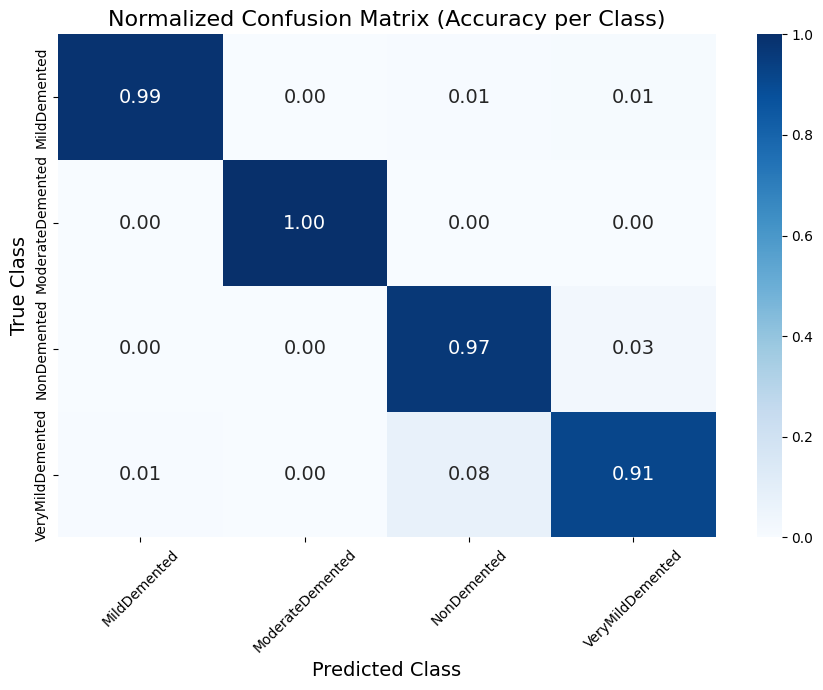

In [7]:
# BLOCK 7: Final Evaluation Metrics
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt


y_true = []
y_pred_probs = []

# Iterate through the validation dataset
for images, labels in val_ds:
    # Get model predictions
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

    # Convert true labels back from one-hot encoding
    true_labels_batch = tf.argmax(labels, axis=1).numpy()
    y_true.extend(true_labels_batch)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Advanced Medical Metrics
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print("\n--- Final Model Metrics ---")
print(f"Cohen's Kappa: {kappa:.4f} (Measures agreement, >0.8 is excellent)")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f} (1.0 is perfect)")

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Normalized Confusion Matrix
cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(9, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Normalized Confusion Matrix (Accuracy per Class)', fontsize=16)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


GRAD-CAM EXPLAINABILITY REPORT
Predicted Diagnosis: ModerateDemented
Model Confidence:    100.00%

What the colors mean:
🔴 RED / ORANGE: Critical impact. The model heavily relied on these specific textures/shapes to make its diagnosis.
🟡 YELLOW / GREEN: Moderate impact. These areas contributed slightly to the decision.
🔵 BLUE: Ignored. The model determined these areas were irrelevant to this specific diagnosis.


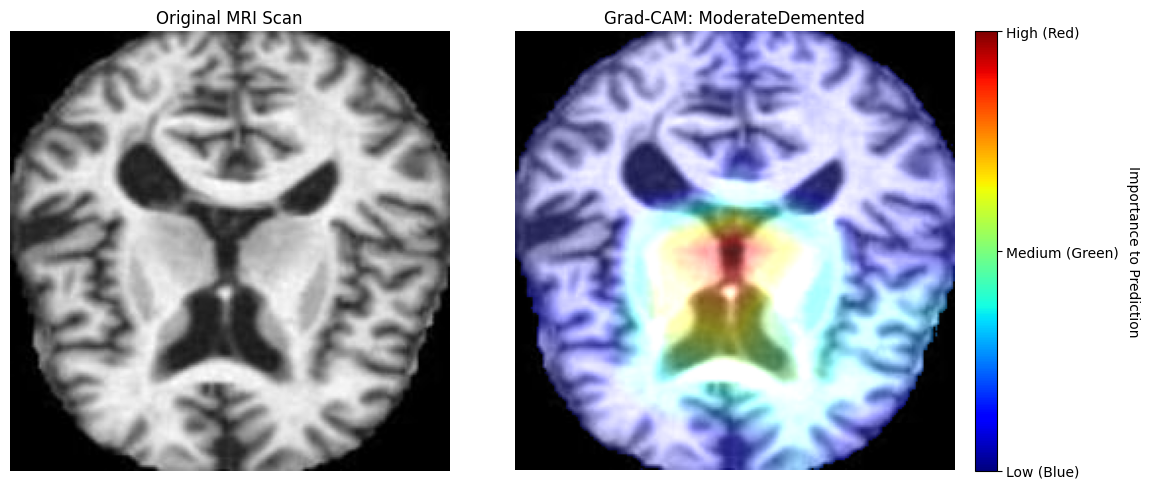

In [8]:
# BLOCK 8: The Final Perfected Grad-CAM (With Legends & Interpretations)
import os
import cv2
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import applications
import matplotlib.pyplot as plt

def generate_final_gradcam(img_path, model, class_names):
    # 1. Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Extract the nested ResNet50 model and the data augmentation layer
    base_model = model.get_layer('resnet50')
    data_augmentation_layer = model.get_layer('mri_augmentation_clean')
    last_conv_layer = base_model.get_layer('conv5_block3_out')

    # 3. Create sub-models for gradients
    inner_grad_model = tf.keras.Model([base_model.inputs], [last_conv_layer.output, base_model.output])

    top_input = tf.keras.Input(shape=base_model.output.shape[1:])
    x_top = top_input
    resnet_idx = model.layers.index(base_model)
    for layer in model.layers[resnet_idx+1:]:
        x_top = layer(x_top)
    top_model = tf.keras.Model(top_input, x_top)

    # 4. Record gradients
    with tf.GradientTape() as tape:
        x = tf.cast(img_array, tf.float32)
        x = data_augmentation_layer(x, training=False)
        x = applications.resnet50.preprocess_input(x)

        conv_outputs, base_outputs = inner_grad_model(x)
        tape.watch(conv_outputs)
        preds = top_model(base_outputs)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        predicted_class_name = class_names[pred_index.numpy()]
        confidence = preds[0][pred_index] * 100

    # 5. Calculate heatmap
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # 6. Superimpose over original image with background masking
    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (224, 224))

    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    _, brain_mask = cv2.threshold(gray, 10, 1, cv2.THRESH_BINARY)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_masked = heatmap_resized * brain_mask

    heatmap_color = np.uint8(255 * heatmap_masked)
    heatmap_color_mapped = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)

    brain_mask_3d = np.repeat(brain_mask[:, :, np.newaxis], 3, axis=2)
    heatmap_color_mapped = heatmap_color_mapped * brain_mask_3d

    superimposed_img = heatmap_color_mapped * 0.4 + img_cv
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

    # --- NEW: PRINT EXPLANATIONS ---
    print("=" * 60)
    print("GRAD-CAM EXPLAINABILITY REPORT")
    print("=" * 60)
    print(f"Predicted Diagnosis: {predicted_class_name}")
    print(f"Model Confidence:    {confidence:.2f}%\n")
    print("What the colors mean:")
    print("🔴 RED / ORANGE: Critical impact. The model heavily relied on these specific textures/shapes to make its diagnosis.")
    print("🟡 YELLOW / GREEN: Moderate impact. These areas contributed slightly to the decision.")
    print("🔵 BLUE: Ignored. The model determined these areas were irrelevant to this specific diagnosis.")
    print("=" * 60)

    # 7. Display with Colorbar
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].set_title("Original MRI Scan")
    axes[0].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')

    axes[1].set_title(f"Grad-CAM: {predicted_class_name}")
    im = axes[1].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    axes[1].axis('off')

    # Add a standalone colorbar to explain the heatmap scale visually
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Importance to Prediction', rotation=270, labelpad=15)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low (Blue)', 'Medium (Green)', 'High (Red)'])

    plt.tight_layout()
    plt.show()

# Test it on a random image from the ModerateDemented class
# (Make sure to update the path if needed)
test_class = "ModerateDemented"
class_folder = os.path.join("/content/drive/MyDrive/Alzheimer_Cleaned_Dataset", test_class)
image_files = [os.path.join(class_folder, f) for f in os.listdir(class_folder) if f.endswith('.jpg')]
random_image_path = random.choice(image_files)

generate_final_gradcam(random_image_path, model, class_names)

Generating visualization dashboard...


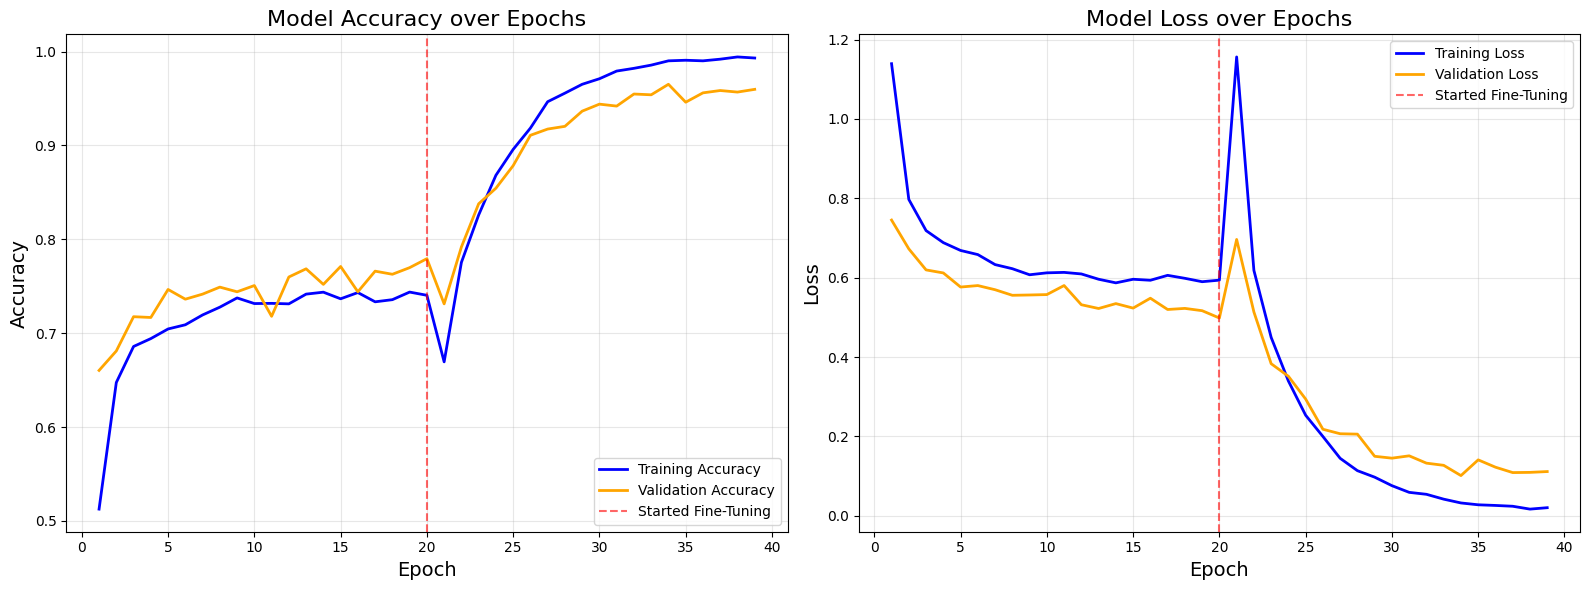


Calculating ROC Curve data (Making predictions on validation set)...


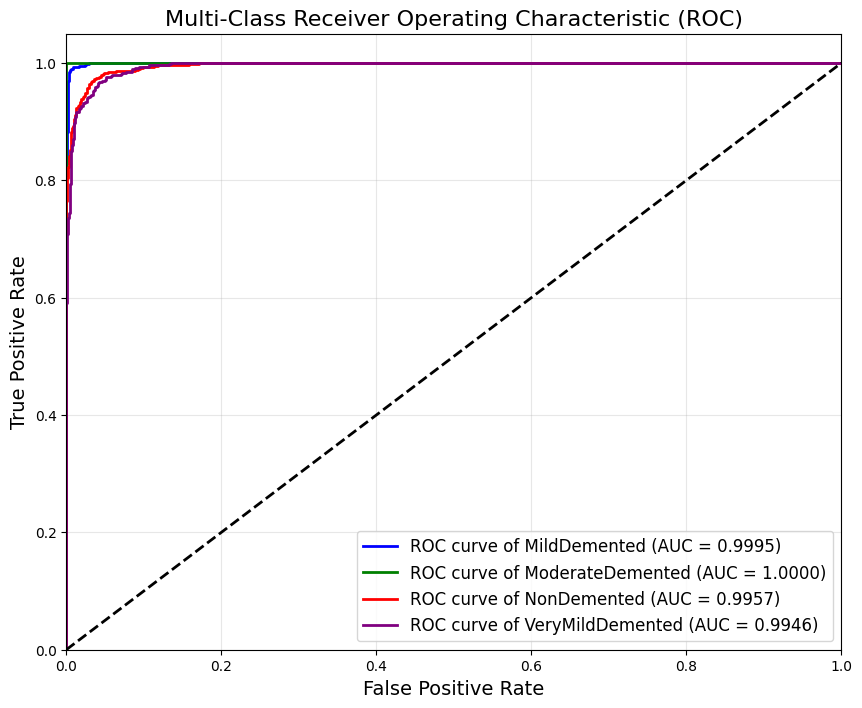

In [9]:
# BLOCK 9: Comprehensive Visualization Dashboard
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Generating visualization dashboard...")

# ==========================================
# 1. STITCH AND PLOT TRAINING HISTORY
# ==========================================
# Combine Phase 1 and Phase 2 histories
acc = history_phase1.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_phase1.history['loss'] + history_fine.history['loss']
val_loss = history_phase1.history['val_loss'] + history_fine.history['val_loss']

# Find the epoch where Phase 2 started
initial_epochs = len(history_phase1.history['accuracy'])
total_epochs = range(1, len(acc) + 1)

plt.figure(figsize=(16, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(total_epochs, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(total_epochs, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.axvline(x=initial_epochs, color='red', linestyle='--', alpha=0.6, label='Started Fine-Tuning')
plt.title('Model Accuracy over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(total_epochs, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(total_epochs, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.axvline(x=initial_epochs, color='red', linestyle='--', alpha=0.6, label='Started Fine-Tuning')
plt.title('Model Loss over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# 2. PLOT MULTI-CLASS ROC CURVE
# ==========================================
print("\nCalculating ROC Curve data (Making predictions on validation set)...")

y_true = []
y_pred_probs = []

# Extract data from the validation dataset
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    true_labels_batch = tf.argmax(labels, axis=1).numpy()
    y_true.extend(true_labels_batch)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Binarize the true labels (Required for multi-class ROC)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

# Set up dictionaries
fpr = {}
tpr = {}
roc_auc = {}

# Calculate ROC for each class
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC Curve
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple']

for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (AUC = {roc_auc[i]:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class Receiver Operating Characteristic (ROC)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


EXTRACTING PREDICTIONS FOR STATISTICAL ANALYSIS

--- 1. Advanced Mathematical Metrics ---
Log Loss: 0.1013 (Closer to 0 is better)
Hamming Loss: 0.0348 (Fraction of labels that are incorrectly predicted)
Jaccard Score (Macro): 0.9373 (Intersection over Union of predictions)

--- 2. 95% Confidence Intervals (StatsModels) ---
Total Validation Samples: 2411
Raw Accuracy: 96.52%
We are 95% confident the true real-world accuracy lies between: [95.71%, 97.18%]

--- 3. Detailed Per-Class Breakdown ---
                  Precision  Recall  F1-Score  Support  Avg Confidence
MildDemented         0.9880  0.9863    0.9872    586.0          0.9785
ModerateDemented     1.0000  1.0000    1.0000    544.0          0.9987
NonDemented          0.9184  0.9682    0.9426    628.0          0.9613
VeryMildDemented     0.9629  0.9142    0.9379    653.0          0.9379

Generating Confidence Distribution Graphs...


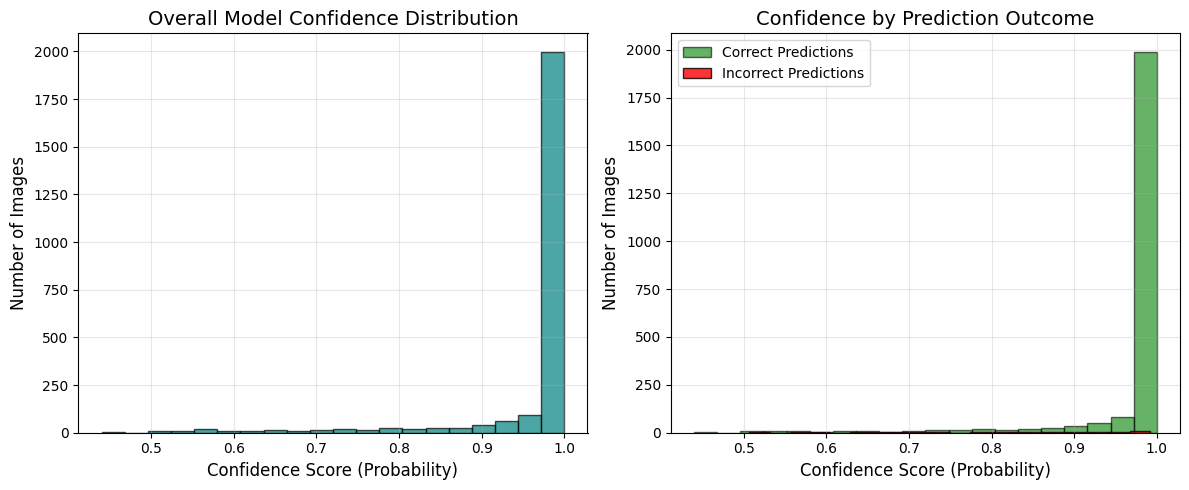


--- 5. Model Architecture Complexity ---
Total Parameters: 23,595,908
Trainable Parameters: 14,984,196 (Fine-tuned ResNet layers + Custom Top)
Frozen Parameters: 8,611,712 (Base ResNet layers)


In [10]:
# BLOCK 10: Advanced Statistical & Confidence Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss, hamming_loss, jaccard_score, precision_score, recall_score, f1_score, cohen_kappa_score
from statsmodels.stats.proportion import proportion_confint
import tensorflow as tf # Adding this just in case it isn't imported globally

print("=" * 60)
print("EXTRACTING PREDICTIONS FOR STATISTICAL ANALYSIS")
print("=" * 60)

y_true = []
y_pred_proba = []

# Extract predictions once to save time
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_proba.extend(preds)
    true_labels_batch = tf.argmax(labels, axis=1).numpy()
    y_true.extend(true_labels_batch)

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = np.argmax(y_pred_proba, axis=1)
confidence_scores = np.max(y_pred_proba, axis=1)

# ==========================================
# 1. ADVANCED CLASSIFICATION METRICS
# ==========================================
print("\n--- 1. Advanced Mathematical Metrics ---")
logloss = log_loss(y_true, y_pred_proba)
hamming = hamming_loss(y_true, y_pred)
jaccard_macro = jaccard_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Log Loss: {logloss:.4f} (Closer to 0 is better)")
print(f"Hamming Loss: {hamming:.4f} (Fraction of labels that are incorrectly predicted)")
print(f"Jaccard Score (Macro): {jaccard_macro:.4f} (Intersection over Union of predictions)")

# ==========================================
# 2. STATISTICAL CONFIDENCE INTERVALS
# ==========================================
print("\n--- 2. 95% Confidence Intervals (StatsModels) ---")
n_samples = len(y_true)
correct_predictions = np.sum(y_true == y_pred)
accuracy = correct_predictions / n_samples

# Calculate 95% Confidence Interval using statsmodels
lower_bound, upper_bound = proportion_confint(count=correct_predictions, nobs=n_samples, alpha=0.05, method='wilson')

print(f"Total Validation Samples: {n_samples}")
print(f"Raw Accuracy: {accuracy * 100:.2f}%")
print(f"We are 95% confident the true real-world accuracy lies between: [{lower_bound * 100:.2f}%, {upper_bound * 100:.2f}%]")

# ==========================================
# 3. PER-CLASS DETAILED DATAFRAME
# ==========================================
print("\n--- 3. Detailed Per-Class Breakdown ---")
metrics_df = pd.DataFrame(index=class_names)

for i, class_name in enumerate(class_names):
    y_true_binary = (y_true == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)

    metrics_df.loc[class_name, 'Precision'] = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    metrics_df.loc[class_name, 'Recall'] = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    metrics_df.loc[class_name, 'F1-Score'] = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    metrics_df.loc[class_name, 'Support'] = np.sum(y_true_binary)

    # --- THE FIX IS HERE ---
    # Average confidence when predicting this class.
    # We create a strict True/False boolean mask of where the model predicted class 'i'
    pred_mask = (y_pred == i)

    # We use the boolean mask to pull the probabilities, preventing the NumPy integer indexing bug
    class_confidences = y_pred_proba[pred_mask, i]
    metrics_df.loc[class_name, 'Avg Confidence'] = np.mean(class_confidences) if len(class_confidences) > 0 else 0

print(metrics_df.round(4))

# ==========================================
# 4. CONFIDENCE DISTRIBUTION VISUALIZATION
# ==========================================
print("\nGenerating Confidence Distribution Graphs...")
plt.figure(figsize=(12, 5))

# Overall Confidence Histogram
plt.subplot(1, 2, 1)
plt.hist(confidence_scores, bins=20, alpha=0.7, color='teal', edgecolor='black')
plt.xlabel('Confidence Score (Probability)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Overall Model Confidence Distribution', fontsize=14)
plt.grid(alpha=0.3)

# Confidence: Correct vs Incorrect
correct_conf = confidence_scores[y_true == y_pred]
incorrect_conf = confidence_scores[y_true != y_pred]

plt.subplot(1, 2, 2)
if len(correct_conf) > 0:
    plt.hist(correct_conf, bins=20, alpha=0.6, label='Correct Predictions', color='green', edgecolor='black')
if len(incorrect_conf) > 0:
    plt.hist(incorrect_conf, bins=20, alpha=0.8, label='Incorrect Predictions', color='red', edgecolor='black')
plt.xlabel('Confidence Score (Probability)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Confidence by Prediction Outcome', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. MODEL COMPLEXITY
# ==========================================
print("\n--- 5. Model Architecture Complexity ---")
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} (Fine-tuned ResNet layers + Custom Top)")
print(f"Frozen Parameters: {non_trainable_params:,} (Base ResNet layers)")
print("=" * 60)

In [11]:
# Save the model
model.save('alzheimer_model.keras')

# Download it to your local machine
from google.colab import files
files.download('alzheimer_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>